In [1]:
# Import Libraries
import pandas as pd
import numpy as np
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
import pickle

In [15]:
import pandas as pd
import numpy as np

# Generate synthetic daily weather data for Mumbai (2021-2023)
np.random.seed(7)
dates = pd.date_range(start='2021-01-01', end='2023-12-31', freq='D')
n = len(dates)
day_of_year = np.array([d.timetuple().tm_yday for d in dates])

# Mumbai climate patterns
temperature = 28 + 5 * np.sin(2 * np.pi * (day_of_year - 60) / 365) + np.random.normal(0, 1.2, n)
humidity    = 72 + 20 * np.sin(2 * np.pi * (day_of_year - 150) / 365) + np.random.normal(0, 5, n)
pressure    = 1010 + 5 * np.sin(2 * np.pi * (day_of_year - 30) / 365) + np.random.normal(0, 2, n)
wind_speed  = 12 + 8 * np.sin(2 * np.pi * (day_of_year - 140) / 365) + np.random.normal(0, 2, n)

df = pd.DataFrame({
    'date'       : dates,
    'temperature': np.round(temperature, 2),
    'humidity'   : np.round(np.clip(humidity, 0, 100), 2),
    'pressure'   : np.round(pressure, 2),
    'wind_speed' : np.round(np.clip(wind_speed, 0, 60), 2)
})

df.to_csv('mumbai_weather_3years.csv', index=False)
print('Dataset created successfully!')
print(df.head())
print('Total rows:', len(df))


         date  temperature  humidity  pressure  wind_speed  rainfall
0  2023-01-01         12.5        79     994.9         6.0       0.0
1  2023-01-02         12.2        78     995.8         5.0       0.0
2  2023-01-03         10.6        85     996.7         6.6       0.0
3  2023-01-04          9.7        87     997.1         8.5       0.0
4  2023-01-05          8.9        89     998.0         8.1       0.0

✅ Dataset saved successfully as 'delhi_weather_3years.csv'
Total rows: 1223


In [20]:
df = pd.read_csv('mumbai_weather_3years.csv')

print('Dataset Shape:', df.shape)
print(df.head())
print('\nMissing Values:\n', df.isnull().sum())

# Select Features
FEATURES = [
    'temperature',
    'humidity',
    'pressure',
    'wind_speed'
]

df = df[FEATURES].dropna().reset_index(drop=True)

# Remove extreme outliers
df['temperature'] = df['temperature'].clip(-5, 45)
df['humidity']    = df['humidity'].clip(0, 100)
df['pressure']    = df['pressure'].clip(950, 1050)
df['wind_speed']  = df['wind_speed'].clip(0, 80)

print('\nFinal Data Shape:', df.shape)

# Scaling
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# Create Sequences
SEQ_LEN   = 30
HORIZON   = 10
N_FEATURES = len(FEATURES)

def create_sequences(data, seq_len=30, horizon=10):
    X, y = [], []
    for i in range(len(data) - seq_len - horizon):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len:i+seq_len+horizon])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, seq_len=SEQ_LEN, horizon=HORIZON)

# Reshape target: (samples, 10, 4) -> (samples, 40)
y = y.reshape(y.shape[0], HORIZON * N_FEATURES)

print('\nX Shape:', X.shape)
print('y Shape:', y.shape)

# Train Test Split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print('\nTrain Shape:', X_train.shape)
print('Test Shape :', X_test.shape)

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# RNN Model
rnn_model = Sequential([
    SimpleRNN(64, input_shape=(SEQ_LEN, N_FEATURES)),
    Dense(HORIZON * N_FEATURES)
])
rnn_model.compile(optimizer='adam', loss='mse')
print('\nTraining RNN Model...\n')
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=30, batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop], verbose=1
)

# LSTM Model
lstm_model = Sequential([
    LSTM(64, input_shape=(SEQ_LEN, N_FEATURES)),
    Dense(HORIZON * N_FEATURES)
])
lstm_model.compile(optimizer='adam', loss='mse')
print('\nTraining LSTM Model...\n')
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=30, batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop], verbose=1
)


Dataset Shape: (1223, 6)
         date  temperature  humidity  pressure  wind_speed  rainfall
0  2023-01-01         12.5        79     994.9         6.0       0.0
1  2023-01-02         12.2        78     995.8         5.0       0.0
2  2023-01-03         10.6        85     996.7         6.6       0.0
3  2023-01-04          9.7        87     997.1         8.5       0.0
4  2023-01-05          8.9        89     998.0         8.1       0.0

Missing Values:
 date           0
temperature    0
humidity       0
pressure       0
wind_speed     0
rainfall       0
dtype: int64

Final Data Shape: (1223, 4)

X Shape: (1183, 30, 4)
y Shape: (1183, 40)

Train Shape: (946, 30, 4)
Test Shape : (237, 30, 4)

Training RNN Model...

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.1550 - val_loss: 0.0456
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0409 - val_loss: 0.0322
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0277 - val_loss: 0.0213
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0202 - val_loss: 0.0205
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0182 - val_loss: 0.0180
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0172 - val_loss: 0.0168
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0166 - val_loss: 0.0164
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0161 - val_loss: 0.0164
Epoch 9/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0157 - val_loss: 0.0159
Epoch 10/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0155 - val_loss: 0.0158
Epoch 11/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0154 - val_loss: 0.0170
Epoch 12/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0153 - val_loss

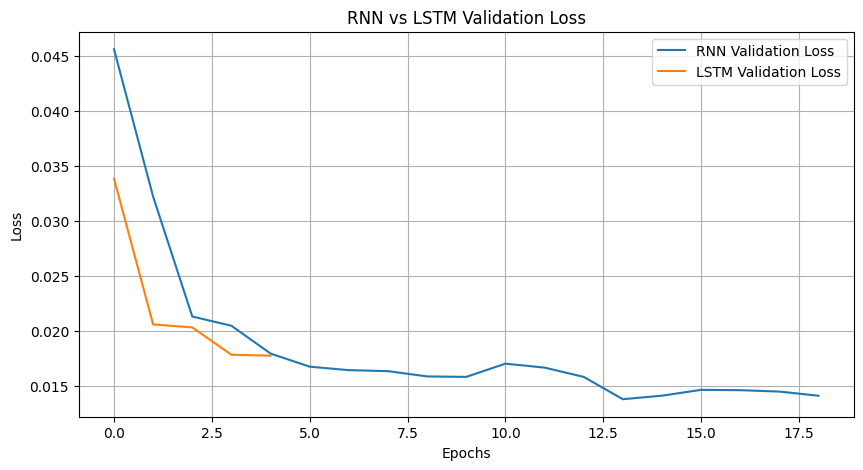


========== MODEL EVALUATION ==========

RNN RMSE : 0.1175
LSTM RMSE: 0.1840

RNN MAE  : 0.0936
LSTM MAE : 0.1501

Approx RNN Accuracy : 88.25%
Approx LSTM Accuracy: 81.60%


In [21]:
# Loss Graph
plt.figure(figsize=(10, 5))
plt.plot(rnn_history.history["val_loss"], label="RNN Validation Loss")
plt.plot(lstm_history.history["val_loss"], label="LSTM Validation Loss")
plt.title("RNN vs LSTM Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Predictions
rnn_pred = rnn_model.predict(X_test, verbose=0)
lstm_pred = lstm_model.predict(X_test, verbose=0)

# Evaluation
rnn_rmse = np.sqrt(mean_squared_error(y_test, rnn_pred))
lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_pred))

rnn_mae = mean_absolute_error(y_test, rnn_pred)
lstm_mae = mean_absolute_error(y_test, lstm_pred)

print("\n========== MODEL EVALUATION ==========\n")
print(f"RNN RMSE : {rnn_rmse:.4f}")
print(f"LSTM RMSE: {lstm_rmse:.4f}")

print(f"\nRNN MAE  : {rnn_mae:.4f}")
print(f"LSTM MAE : {lstm_mae:.4f}")

# Approximate accuracy (informal metric)
rnn_accuracy = max(0, 100 - rnn_rmse * 100)
lstm_accuracy = max(0, 100 - lstm_rmse * 100)

print(f"\nApprox RNN Accuracy : {rnn_accuracy:.2f}%")
print(f"Approx LSTM Accuracy: {lstm_accuracy:.2f}%")


========== 10 DAYS FORECAST ==========

      Day   RNN Temp  RNN Humidity  RNN Pressure  RNN Wind  LSTM Temp  \
0   Day 1  30.469999     49.880001    983.059998      9.56  24.190001   
1   Day 2  28.120001     49.689999    982.859985      9.23  27.530001   
2   Day 3  27.559999     49.980000    981.140015      8.64  25.760000   
3   Day 4  28.430000     42.750000    983.630005      7.32  26.000000   
4   Day 5  28.469999     55.310001    983.950012      7.45  22.450001   
5   Day 6  29.270000     53.220001    981.820007     10.43  29.260000   
6   Day 7  31.379999     44.680000    980.510010      9.06  25.889999   
7   Day 8  29.190001     53.410000    981.760010      9.48  24.350000   
8   Day 9  27.549999     47.980000    981.190002      7.98  23.049999   
9  Day 10  30.100000     48.770000    983.630005      7.92  25.629999   

   LSTM Humidity  LSTM Pressure  LSTM Wind  
0      70.160004     985.520020       8.37  
1      61.090000     983.760010       9.00  
2      52.939999    

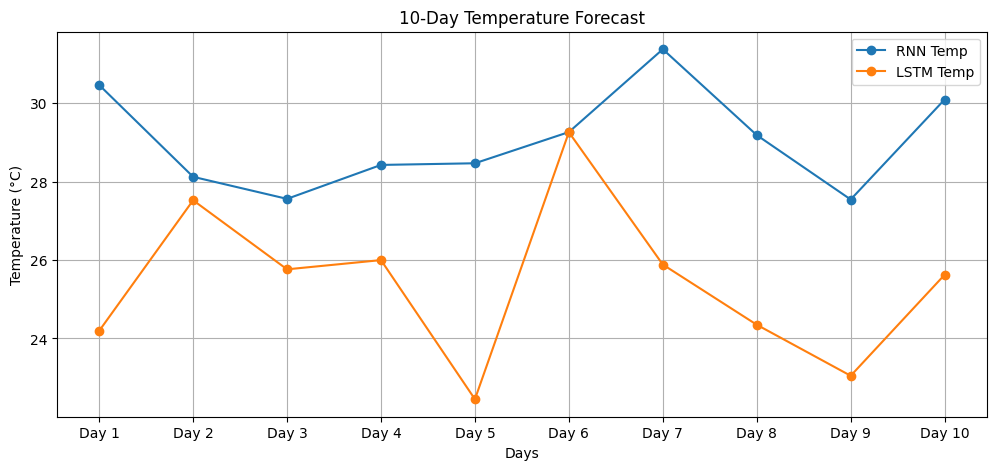

In [23]:
# Future Forecast
last_seq = scaled_data[-SEQ_LEN:].reshape(1, SEQ_LEN, N_FEATURES)

# RNN Forecast
future_rnn = rnn_model.predict(last_seq, verbose=0)
future_rnn = future_rnn.reshape(HORIZON, N_FEATURES)
future_rnn = scaler.inverse_transform(future_rnn)

# LSTM Forecast
future_lstm = lstm_model.predict(last_seq, verbose=0)
future_lstm = future_lstm.reshape(HORIZON, N_FEATURES)
future_lstm = scaler.inverse_transform(future_lstm)

# Clip to realistic ranges
def clip_forecast(arr):
    arr = arr.copy()
    arr[:, 0] = np.clip(arr[:, 0], -10, 50)   # Temperature
    arr[:, 1] = np.clip(arr[:, 1], 0, 100)    # Humidity
    arr[:, 2] = np.clip(arr[:, 2], 950, 1050) # Pressure
    arr[:, 3] = np.clip(arr[:, 3], 0, 150)    # Wind Speed
    return arr

future_rnn = clip_forecast(future_rnn)
future_lstm = clip_forecast(future_lstm)

# Forecaste DataFrame
days = [f"Day {i+1}" for i in range(HORIZON)]

forecast_df = pd.DataFrame({
    "Day": days,

    "RNN Temp": future_rnn[:, 0],
    "RNN Humidity": future_rnn[:, 1],
    "RNN Pressure": future_rnn[:, 2],
    "RNN Wind": future_rnn[:, 3],

    "LSTM Temp": future_lstm[:, 0],
    "LSTM Humidity": future_lstm[:, 1],
    "LSTM Pressure": future_lstm[:, 2],
    "LSTM Wind": future_lstm[:, 3],
})

print("\n========== 10 DAYS FORECAST ==========\n")
print(forecast_df.round(2))

# Temperature Graph
plt.figure(figsize=(12, 5))
plt.plot(days, future_rnn[:, 0], marker="o", label="RNN Temp")
plt.plot(days, future_lstm[:, 0], marker="o", label="LSTM Temp")
plt.title("10-Day Temperature Forecast - Mumbai")
plt.xlabel("Days")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
# Save Model
rnn_model.save('mumbai_weather_rnn_model.h5')
lstm_model.save('mumbai_weather_lstm_model.h5')

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('Models saved successfully!')
